# Challenge 02 — Fase 1: Auditoría de Calidad y Transparencia

**Curso:** Fundamentos en Ciencia de Datos (Maestría) — EAFIT · 2026-1
**Cliente:** TechLogistics S.A.S. (ficticio)
**Objetivo de esta libreta:** *antes* de construir el dashboard, diagnosticar el estado
real de los tres datasets crudos y dejar **evidencia trazable** de su calidad.

> Un consultor senior no limpia datos sin dejar rastro. Aquí calculamos un **Health Score**
> por dataset y documentamos cada problema detectado. La limpieza definitiva vive en
> `src/cleaning.py`; esta libreta es el **diagnóstico**.

### Qué produce esta libreta
1. Perfilamiento de los 3 datasets (tipos, nulos, duplicados, rangos).
2. Detección de "basura" documentada (GIGO): valores imposibles, encoding roto, outliers.
3. `results/tabla_diagnostico_gigo.csv` — tabla resumen de hallazgos.
4. Figuras clave en `results/figuras/`.


## 0. Configuración e imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Rutas relativas a la raíz del repo. Ejecuta la libreta desde notebooks/
# o ajusta BASE si la corres desde otro sitio.
BASE = ".."
RAW = os.path.join(BASE, "data", "raw")
RESULTS = os.path.join(BASE, "results")
FIGURES = os.path.join(RESULTS, "figuras")
os.makedirs(FIGURES, exist_ok=True)

INV_PATH = os.path.join(RAW, "inventario_central_v2.csv")
TRX_PATH = os.path.join(RAW, "transacciones_logistica_v2.csv")
FB_PATH  = os.path.join(RAW, "feedback_clientes_v2.csv")
print("Rutas configuradas. Archivos esperados en:", RAW)


Rutas configuradas. Archivos esperados en: ..\data\raw


### Nota sobre el *encoding*
Los ejemplos muestran texto corrupto (`FÃsico`, `MedellÃn`, `SÃ`, `25-30 dÃas`): es un
archivo guardado en **latin-1 / cp1252** leído como UTF-8. Intentamos leer con `utf-8`
y si falla usamos `latin-1`. **No corregimos todavía** — solo dejamos constancia del problema.


In [2]:
def cargar_csv(path, nombre):
    """Lee un CSV crudo probando encodings. NO transforma nada."""
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[{nombre}] leído con encoding='{enc}' -> {df.shape[0]} filas x {df.shape[1]} cols")
            return df, enc
        except (UnicodeDecodeError, FileNotFoundError) as e:
            if isinstance(e, FileNotFoundError):
                print(f"[{nombre}] ARCHIVO NO ENCONTRADO en {path}")
                return None, None
            continue
    print(f"[{nombre}] no se pudo leer con los encodings probados")
    return None, None

df_inv, enc_inv = cargar_csv(INV_PATH, "inventario")
df_trx, enc_trx = cargar_csv(TRX_PATH, "transacciones")
df_fb,  enc_fb  = cargar_csv(FB_PATH,  "feedback")


[inventario] leído con encoding='utf-8' -> 2500 filas x 8 cols
[transacciones] leído con encoding='utf-8' -> 10000 filas x 10 cols
[feedback] leído con encoding='utf-8' -> 4500 filas x 9 cols


## 1. Función de perfilamiento reutilizable

Una sola función que aplicamos a los tres datasets, para no repetir código.
Reporta forma, tipos, % de nulos por columna, duplicados y memoria.


In [14]:
def perfilar(df, nombre):
    """Perfilamiento básico de un DataFrame. Devuelve un resumen por columna."""
    print("=" * 70)
    print(f"DATASET: {nombre}  ->  {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print("=" * 70)

    print("\n--- Tipos y no-nulos (info) ---")
    df.info()

    print("\n--- % de nulos por columna ---")
    nul = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
    print(nul.to_string())

    dup = df.duplicated().sum()
    print(f"\n--- Duplicados exactos (fila completa): {dup:,} ---")

    print("\n--- Cardinalidad (valores únicos por columna) ---")
    print(df.nunique().sort_values().to_string())

    return nul, dup


## 2. Dataset 1 — Inventario Central

Maestro de productos (ERP). Problemas esperados según el reto: existencias negativas, costos atípicos ($0.01 a $850k), `Lead_Time_Dias` mezclado (número vs texto `25-30 días`), nulos en stock, fechas de última revisión.

In [15]:
nul_inv, dup_inv = perfilar(df_inv, "inventario_central_v2")
df_inv.head()

DATASET: inventario_central_v2  ->  2,500 filas x 8 columnas

--- Tipos y no-nulos (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SKU_ID              2500 non-null   str    
 1   Categoria           2500 non-null   str    
 2   Stock_Actual        2400 non-null   float64
 3   Costo_Unitario_USD  2500 non-null   float64
 4   Punto_Reorden       2500 non-null   int64  
 5   Lead_Time_Dias      2097 non-null   str    
 6   Bodega_Origen       2500 non-null   str    
 7   Ultima_Revision     2500 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 156.4 KB

--- % de nulos por columna ---
Lead_Time_Dias        16.12
Stock_Actual           4.00
Categoria              0.00
SKU_ID                 0.00
Costo_Unitario_USD     0.00
Punto_Reorden          0.00
Bodega_Origen          0.00
Ultima_Revision        0.00

--- 

,SKU_ID,Categoria,Stock_Actual,Costo_Unitario_USD,Punto_Reorden,Lead_Time_Dias,Bodega_Origen,Ultima_Revision
0,PROD-1000,smart-phone,NaN,870.38,259,25-30 días,Norte,2025-11-17
1,PROD-1001,Accesorios,476.0,1397.26,169,25-30 días,Norte,2024-03-05
2,PROD-1002,Monitores,1209.0,611.62,214,5,Sur,2024-06-21
3,PROD-1003,smart-phone,1825.0,145.94,187,10,Sur,2025-01-07
4,PROD-1004,Smartphones,1713.0,77.78,105,5,Sur,2024-07-04


### 2.1 Diagnósticos específicos de inventario

In [5]:
# Stock negativo (imposible físicamente)
if "Stock_Actual" in df_inv.columns:
    stock_neg = (pd.to_numeric(df_inv["Stock_Actual"], errors="coerce") < 0).sum()
    print(f"Stock_Actual negativo: {stock_neg} registros")

# Costo unitario: rango sospechoso
if "Costo_Unitario_USD" in df_inv.columns:
    cu = pd.to_numeric(df_inv["Costo_Unitario_USD"], errors="coerce")
    print(f"Costo_Unitario_USD -> min: {cu.min()}, max: {cu.max()}")
    print(f"  Costos <= 0.01: {(cu <= 0.01).sum()} | Costos >= 100000: {(cu >= 100000).sum()}")

# Lead_Time_Dias: ¿cuántos NO son numéricos puros? (ej '25-30 días')
if "Lead_Time_Dias" in df_inv.columns:
    lt_num = pd.to_numeric(df_inv["Lead_Time_Dias"], errors="coerce")
    no_num = df_inv["Lead_Time_Dias"].notna() & lt_num.isna()
    print(f"\nLead_Time_Dias NO numéricos (texto tipo '25-30 días'): {no_num.sum()}")
    print("Ejemplos de valores no numéricos:")
    print(df_inv.loc[no_num, "Lead_Time_Dias"].value_counts().head(10).to_string())

# Categorías: inconsistencias de texto/encoding
if "Categoria" in df_inv.columns:
    print("\nCategorías únicas (ojo a encoding/mayúsculas):")
    print(df_inv["Categoria"].value_counts(dropna=False).to_string())


Stock_Actual negativo: 60 registros
Costo_Unitario_USD -> min: 0.05, max: 850000.0
  Costos <= 0.01: 0 | Costos >= 100000: 1

Lead_Time_Dias NO numéricos (texto tipo '25-30 días'): 887
Ejemplos de valores no numéricos:
Lead_Time_Dias
25-30 días    454
Inmediato     433

Categorías únicas (ojo a encoding/mayúsculas):
Categoria
Laptops        329
Monitores      327
Smartphones    314
Tablets        309
Accesorios     307
smart-phone    306
???            305
LAPTOP         303


## 3. Dataset 2 — Transacciones Logística

Histórico de ventas. Problemas esperados: integridad referencial (SKUs que no están en inventario = *venta fantasma*), formatos de fecha variados, `Tiempo_Entrega_Real` con outliers de 999 días, cantidades negativas, `Costo_Envio` vacío, ciudades inconsistentes.

In [6]:
nul_trx, dup_trx = perfilar(df_trx, "transacciones_logistica_v2")
df_trx.head()

DATASET: transacciones_logistica_v2  ->  10,000 filas x 10 columnas

--- Tipos y no-nulos (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaccion_ID       10000 non-null  str    
 1   SKU_ID               10000 non-null  str    
 2   Fecha_Venta          10000 non-null  str    
 3   Cantidad_Vendida     10000 non-null  int64  
 4   Precio_Venta_Final   10000 non-null  float64
 5   Costo_Envio          9166 non-null   float64
 6   Tiempo_Entrega_Real  10000 non-null  int64  
 7   Estado_Envio         8317 non-null   str    
 8   Ciudad_Destino       10000 non-null  str    
 9   Canal_Venta          10000 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 781.4 KB

--- % de nulos por columna ---
Estado_Envio           16.83
Costo_Envio             8.34
SKU_ID                  0.00
Transaccion_ID         

,Transaccion_ID,SKU_ID,Fecha_Venta,Cantidad_Vendida,Precio_Venta_Final,Costo_Envio,Tiempo_Entrega_Real,Estado_Envio,Ciudad_Destino,Canal_Venta
0,TRX-10000,PROD-3619,25/04/2025,-5,1752.48,NaN,999,Entregado,Bucaramanga,Físico
1,TRX-10001,PROD-1456,29/07/2025,12,686.88,67.16,29,Entregado,Ventas_Web,WhatsApp
2,TRX-10002,PROD-1102,31/05/2025,2,402.06,32.55,13,Perdido,MED,Físico
3,TRX-10003,PROD-2126,23/01/2026,4,665.98,62.64,12,Perdido,Medellín,Online
4,TRX-10004,PROD-2003,09/10/2025,5,1222.62,52.91,15,Entregado,BOG,App


### 3.1 Diagnósticos específicos de transacciones

In [7]:
# Cantidad vendida negativa
if "Cantidad_Vendida" in df_trx.columns:
    q = pd.to_numeric(df_trx["Cantidad_Vendida"], errors="coerce")
    print(f"Cantidad_Vendida negativa: {(q < 0).sum()} | cero: {(q == 0).sum()}")

# Tiempo de entrega: outlier 999
if "Tiempo_Entrega_Real" in df_trx.columns:
    te = pd.to_numeric(df_trx["Tiempo_Entrega_Real"], errors="coerce")
    print(f"Tiempo_Entrega_Real -> min: {te.min()}, max: {te.max()}")
    print(f"  Registros con 999 días: {(te == 999).sum()} | > 365 días: {(te > 365).sum()}")

# Costo de envío vacío
if "Costo_Envio" in df_trx.columns:
    ce = pd.to_numeric(df_trx["Costo_Envio"], errors="coerce")
    print(f"Costo_Envio nulo/vacío: {ce.isna().sum()}")

# Ciudad destino: inconsistencias (MED, MedellÃn, Ventas_Web mezclado con ciudades)
if "Ciudad_Destino" in df_trx.columns:
    print("\nCiudad_Destino (valores crudos, ojo inconsistencias):")
    print(df_trx["Ciudad_Destino"].value_counts(dropna=False).to_string())

# Fechas: intentar parsear y ver cuántas fallan / futuras
if "Fecha_Venta" in df_trx.columns:
    f = pd.to_datetime(df_trx["Fecha_Venta"], errors="coerce", dayfirst=True)
    print(f"\nFecha_Venta no parseables: {f.isna().sum()}")
    futuras = (f > pd.Timestamp.now()).sum()
    print(f"Fecha_Venta en el futuro (> hoy): {futuras}")


Cantidad_Vendida negativa: 100 | cero: 0
Tiempo_Entrega_Real -> min: 1, max: 999
  Registros con 999 días: 50 | > 365 días: 50
Costo_Envio nulo/vacío: 834

Ciudad_Destino (valores crudos, ojo inconsistencias):
Ciudad_Destino
Ventas_Web      1290
BOG             1267
Bogotá          1261
Cali            1256
Bucaramanga     1250
Medellín        1234
MED             1223
Barranquilla    1219

Fecha_Venta no parseables: 0
Fecha_Venta en el futuro (> hoy): 0


### 3.2 Integridad referencial — el SKU Fantasma

Cruzamos los SKU de ventas contra el maestro de inventario. Los que no existen son **ventas fantasma**: hay que cuantificar su impacto (Pregunta 3 del reto).

In [8]:
if "SKU_ID" in df_trx.columns and "SKU_ID" in df_inv.columns:
    skus_inv = set(df_inv["SKU_ID"].dropna().unique())
    skus_trx = df_trx["SKU_ID"].dropna()
    fantasma_mask = ~skus_trx.isin(skus_inv)
    n_fantasma = fantasma_mask.sum()
    pct = 100 * n_fantasma / len(skus_trx) if len(skus_trx) else 0
    print(f"Ventas con SKU inexistente en inventario: {n_fantasma:,} ({pct:.1f}% de las ventas)")
    print(f"SKUs fantasma distintos: {skus_trx[fantasma_mask].nunique():,}")
else:
    print("No se puede cruzar: falta columna SKU_ID en algún dataset.")


Ventas con SKU inexistente en inventario: 1,751 (17.5% de las ventas)
SKUs fantasma distintos: 480


## 4. Dataset 3 — Feedback Clientes

Voz del cliente. Problemas esperados: duplicados intencionales, edades imposibles (195), ratings fuera de escala (99 cuando debería ser 1-5), NPS que requiere normalización, `Ticket_Soporte_Abierto` inconsistente (`Sí`/`0`/`No`), texto placeholder (`N/A`, `---`).

In [9]:
nul_fb, dup_fb = perfilar(df_fb, "feedback_clientes_v2")
df_fb.head()

DATASET: feedback_clientes_v2  ->  4,500 filas x 9 columnas

--- Tipos y no-nulos (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Feedback_ID             4500 non-null   str    
 1   Transaccion_ID          4500 non-null   str    
 2   Rating_Producto         4500 non-null   int64  
 3   Rating_Logistica        4500 non-null   int64  
 4   Comentario_Texto        3843 non-null   str    
 5   Recomienda_Marca        3381 non-null   str    
 6   Ticket_Soporte_Abierto  4500 non-null   str    
 7   Edad_Cliente            4500 non-null   int64  
 8   Satisfaccion_NPS        4500 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 316.5 KB

--- % de nulos por columna ---
Recomienda_Marca          24.87
Comentario_Texto          14.60
Feedback_ID                0.00
Rating_Producto            0.00
Transacci

,Feedback_ID,Transaccion_ID,Rating_Producto,Rating_Logistica,Comentario_Texto,Recomienda_Marca,Ticket_Soporte_Abierto,Edad_Cliente,Satisfaccion_NPS
0,FB-8000,TRX-17461,99,4,NaN,NaN,Sí,195,-17.5
1,FB-8001,TRX-17755,4,5,---,Maybe,Sí,59,-41.7
2,FB-8002,TRX-10534,3,4,No volvería,Maybe,0,84,-36.4
3,FB-8003,TRX-12569,2,3,---,NaN,Sí,20,7.4
4,FB-8004,TRX-19159,4,2,Dañado,SI,No,83,61.0


### 4.1 Diagnósticos específicos de feedback

In [10]:
# Rating fuera de escala 1-5
for col in ["Rating_Producto", "Rating_Logistica"]:
    if col in df_fb.columns:
        r = pd.to_numeric(df_fb[col], errors="coerce")
        fuera = ((r < 1) | (r > 5)).sum()
        print(f"{col} -> min: {r.min()}, max: {r.max()} | fuera de rango [1-5]: {fuera}")

# Edad imposible
if "Edad_Cliente" in df_fb.columns:
    e = pd.to_numeric(df_fb["Edad_Cliente"], errors="coerce")
    print(f"\nEdad_Cliente -> min: {e.min()}, max: {e.max()}")
    print(f"  Edades > 100: {(e > 100).sum()} | < 0: {(e < 0).sum()}")

# NPS: rango y signo
if "Satisfaccion_NPS" in df_fb.columns:
    nps = pd.to_numeric(df_fb["Satisfaccion_NPS"], errors="coerce")
    print(f"\nSatisfaccion_NPS -> min: {nps.min()}, max: {nps.max()}")

# Ticket_Soporte_Abierto: valores inconsistentes
if "Ticket_Soporte_Abierto" in df_fb.columns:
    print("\nTicket_Soporte_Abierto (crudo, inconsistente Sí/No/0/1):")
    print(df_fb["Ticket_Soporte_Abierto"].value_counts(dropna=False).to_string())

# Duplicados por Feedback_ID (más allá de fila exacta)
if "Feedback_ID" in df_fb.columns:
    dup_id = df_fb["Feedback_ID"].duplicated().sum()
    print(f"\nFeedback_ID duplicados: {dup_id}")

# Placeholders de texto
if "Comentario_Texto" in df_fb.columns:
    placeholders = df_fb["Comentario_Texto"].isin(["N/A", "---", "", "NA", "n/a"]).sum()
    print(f"Comentarios placeholder (N/A, ---, vacío): {placeholders}")


Rating_Producto -> min: 1, max: 99 | fuera de rango [1-5]: 30
Rating_Logistica -> min: 1, max: 5 | fuera de rango [1-5]: 0

Edad_Cliente -> min: 18, max: 195
  Edades > 100: 23 | < 0: 0

Satisfaccion_NPS -> min: -99.8, max: 99.9

Ticket_Soporte_Abierto (crudo, inconsistente Sí/No/0/1):
Ticket_Soporte_Abierto
Sí    1158
1     1140
0     1117
No    1085

Feedback_ID duplicados: 500
Comentarios placeholder (N/A, ---, vacío): 631


## 5. Health Score por dataset

Un indicador simple y auditable de "salud" de cada tabla, combinando:
- **Completitud**: 1 − (% celdas nulas)
- **Unicidad**: 1 − (% filas duplicadas)

El score final es el promedio, en escala 0–100. Es una *primera foto*; la limpieza
posterior debería subirlo. Guardamos el número para mostrar el **antes vs después**
en la pestaña de Auditoría del dashboard.


In [11]:
def health_score(df, nombre):
    completitud = 1 - df.isna().mean().mean()
    unicidad = 1 - (df.duplicated().sum() / len(df)) if len(df) else 0
    score = round(100 * (completitud + unicidad) / 2, 1)
    return {
        "dataset": nombre,
        "filas": len(df),
        "columnas": df.shape[1],
        "completitud_%": round(100 * completitud, 1),
        "unicidad_%": round(100 * unicidad, 1),
        "health_score": score,
    }

resumen = pd.DataFrame([
    health_score(df_inv, "inventario_central_v2"),
    health_score(df_trx, "transacciones_logistica_v2"),
    health_score(df_fb,  "feedback_clientes_v2"),
])
resumen

,dataset,filas,columnas,completitud_%,unicidad_%,health_score
0,inventario_central_v2,2500,8,97.5,100.0,98.7
1,transacciones_logistica_v2,10000,10,97.5,100.0,98.7
2,feedback_clientes_v2,4500,9,95.6,100.0,97.8


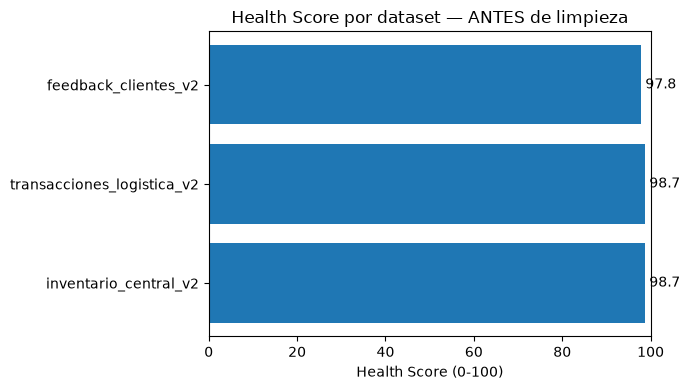

Figura guardada en results/figuras/health_score_antes.png


In [12]:
# Gráfico del Health Score (antes de limpieza)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(resumen["dataset"], resumen["health_score"])
ax.set_xlim(0, 100)
ax.set_xlabel("Health Score (0-100)")
ax.set_title("Health Score por dataset — ANTES de limpieza")
for i, v in enumerate(resumen["health_score"]):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.savefig(f"{FIGURES}/health_score_antes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada en results/figuras/health_score_antes.png")

## 6. Tabla de diagnóstico GIGO

Consolidamos los hallazgos en `results/tabla_diagnostico_gigo.csv`. Esta tabla alimenta
tanto el informe de hallazgos como la **decisión ética** (¿imputar o eliminar?) que se
documenta en la Fase 1. Las columnas quedan listas para que las completes con la acción
final que tomes en `src/cleaning.py`.


In [13]:
diagnostico = []

def add(dataset, columna, problema, magnitud, accion_sugerida):
    diagnostico.append({
        "dataset": dataset, "columna": columna, "problema": problema,
        "magnitud": magnitud, "accion_sugerida": accion_sugerida,
        "accion_final": "", "justificacion": ""
    })

# --- Inventario ---
if df_inv is not None:
    if "Stock_Actual" in df_inv.columns:
        neg = int((pd.to_numeric(df_inv["Stock_Actual"], errors="coerce") < 0).sum())
        add("inventario", "Stock_Actual", "Stock negativo (imposible)", neg, "Revisar: NaN o corregir signo")
        nul = int(pd.to_numeric(df_inv["Stock_Actual"], errors="coerce").isna().sum())
        add("inventario", "Stock_Actual", "Nulos", nul, "Imputar (mediana) o marcar")
    if "Costo_Unitario_USD" in df_inv.columns:
        cu = pd.to_numeric(df_inv["Costo_Unitario_USD"], errors="coerce")
        add("inventario", "Costo_Unitario_USD", "Costos atípicos", int(((cu<=0.01)|(cu>=100000)).sum()), "Winsorizar / revisar (IQR)")
    if "Lead_Time_Dias" in df_inv.columns:
        lt = pd.to_numeric(df_inv["Lead_Time_Dias"], errors="coerce")
        add("inventario", "Lead_Time_Dias", "Texto no numérico (ej '25-30 días')", int((df_inv["Lead_Time_Dias"].notna() & lt.isna()).sum()), "Parsear a número (tomar promedio del rango)")

# --- Transacciones ---
if df_trx is not None:
    if "Cantidad_Vendida" in df_trx.columns:
        q = pd.to_numeric(df_trx["Cantidad_Vendida"], errors="coerce")
        add("transacciones", "Cantidad_Vendida", "Cantidad negativa", int((q<0).sum()), "Revisar: devolución vs error")
    if "Tiempo_Entrega_Real" in df_trx.columns:
        te = pd.to_numeric(df_trx["Tiempo_Entrega_Real"], errors="coerce")
        add("transacciones", "Tiempo_Entrega_Real", "Outlier 999 días", int((te==999).sum()), "Tratar como nulo/centinela")
    if "Costo_Envio" in df_trx.columns:
        add("transacciones", "Costo_Envio", "Nulos", int(pd.to_numeric(df_trx["Costo_Envio"], errors="coerce").isna().sum()), "Imputar (mediana por ciudad)")
    if "SKU_ID" in df_trx.columns and df_inv is not None and "SKU_ID" in df_inv.columns:
        skus_inv = set(df_inv["SKU_ID"].dropna().unique())
        fant = int((~df_trx["SKU_ID"].dropna().isin(skus_inv)).sum())
        add("transacciones", "SKU_ID", "Venta fantasma (SKU sin inventario)", fant, "Decisión de negocio: etiquetar 'sin catálogo'")

# --- Feedback ---
if df_fb is not None:
    for col in ["Rating_Producto", "Rating_Logistica"]:
        if col in df_fb.columns:
            r = pd.to_numeric(df_fb[col], errors="coerce")
            add("feedback", col, "Rating fuera de escala [1-5]", int(((r<1)|(r>5)).sum()), "Tratar como nulo e imputar (moda)")
    if "Edad_Cliente" in df_fb.columns:
        e = pd.to_numeric(df_fb["Edad_Cliente"], errors="coerce")
        add("feedback", "Edad_Cliente", "Edad imposible (>100)", int((e>100).sum()), "NaN e imputar (mediana)")
    if "Feedback_ID" in df_fb.columns:
        add("feedback", "Feedback_ID", "Duplicados", int(df_fb["Feedback_ID"].duplicated().sum()), "Eliminar duplicados (keep first)")

tabla = pd.DataFrame(diagnostico)
out_path = f"{RESULTS}/tabla_diagnostico_gigo.csv"
tabla.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Tabla de diagnóstico guardada en {out_path}  ({len(tabla)} hallazgos)")
tabla

Tabla de diagnóstico guardada en ..\results/tabla_diagnostico_gigo.csv  (12 hallazgos)


,dataset,columna,problema,magnitud,accion_sugerida,accion_final,justificacion
0,inventario,Stock_Actual,Stock negativo (imposible),60,Revisar: NaN o corregir signo,,
1,inventario,Stock_Actual,Nulos,100,Imputar (mediana) o marcar,,
2,inventario,Costo_Unitario_USD,Costos atípicos,1,Winsorizar / revisar (IQR),,
3,inventario,Lead_Time_Dias,Texto no numérico (ej '25-30 días'),887,Parsear a número (tomar promedio del rango),,
4,transacciones,Cantidad_Vendida,Cantidad negativa,100,Revisar: devolución vs error,,
5,transacciones,Tiempo_Entrega_Real,Outlier 999 días,50,Tratar como nulo/centinela,,
6,transacciones,Costo_Envio,Nulos,834,Imputar (mediana por ciudad),,
7,transacciones,SKU_ID,Venta fantasma (SKU sin inventario),1751,Decisión de negocio: etiquetar 'sin catálogo',,
8,feedback,Rating_Producto,Rating fuera de escala [1-5],30,Tratar como nulo e imputar (moda),,
9,feedback,Rating_Logistica,Rating fuera de escala [1-5],0,Tratar como nulo e imputar (moda),,


## 7. Conclusiones de la Fase 1

Completa esta sección con tu lectura de los resultados:

- **Dataset más contaminado:** _(según el Health Score)_
- **Problema más crítico para el negocio:** _(ej. ventas fantasma → ingresos en riesgo)_
- **Decisiones de imputación vs eliminación:** _(justifica media/mediana/moda por columna)_

### Próximo paso
Trasladar cada regla de la `tabla_diagnostico_gigo.csv` a funciones en **`src/cleaning.py`**,
que devolverán `(df_limpio, reporte)` para poder mostrar el **antes vs después** en la
pestaña de Auditoría del dashboard.

> _Recuerda registrar en `docs/declaracion_uso_IA.md` qué partes se apoyaron en IA y cómo
> las validaste._
